# PipelineE K=3 — Separate panel exports for Figures 4 and 5

This notebook recreates the **Figure 4** and **Figure 5** content as **separate exported panels**, so you can assemble the final composite layout manually.

It preserves the same dataset roots and file-path logic as the earlier notebooks, while standardizing:
- larger, more legible font sizes
- congruent titles across Figures 4 and 5
- lighter ranked-bar panels
- separate output files for each panel

## Panel exports

### Figure 4 — State-wise BOLD network organization
- **Fig4A**: state-wise BOLD network heatmaps (`S1`, `S2`, `S3`)
- **Fig4B**: BOLD contrast heatmaps (`S1 - S2`, `S3 - S2`)
- **Fig4C1**: top ranked BOLD network contrasts (`S1 vs S2`)
- **Fig4C2**: top ranked BOLD network contrasts (`S3 vs S2`)

### Figure 5 — Descriptive cross-modal BOLD–EEG block structure
- **Fig5A**: state-wise cross-modal heatmaps (`S1`, `S2`, `S3`)
- **Fig5B**: cross-modal contrast heatmaps (`S1 - S2`, `S3 - S2`)
- **Fig5C1**: top ranked cross-modal contrasts (`S1 vs S2`)
- **Fig5C2**: top ranked cross-modal contrasts (`S3 vs S2`)


In [1]:

from pathlib import Path
import json, math, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)

print("Imports ready.")


Imports ready.


In [2]:

# =========================
# CONFIG
# =========================
RESULT_ROOT = Path(
    "/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/"
    "PipelineE_final_K03_intermediate_nolags_minlen15"
)
FINAL_DIR = RESULT_ROOT / "final"

TEMPLATEFLOW_HOME = Path("/mnt/c/EEGFMRI_PIPELINE/templateflow")
TF_TPL_DIR = TEMPLATEFLOW_HOME / "tpl-MNI152NLin2009cAsym"
DEFAULT_SCHAEFER_TSV = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv"
DEFAULT_BRAINSTORM_TXT = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.txt"

PARCEL_LABELS_FILE = None
TR_SEC = 2.1
NETWORK_ORDER = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
REFERENCE_STATE_OVERRIDE = None
TOP_N_BARS = 10

OUT_DIR = RESULT_ROOT / "manuscript_figures_panel_exports_F4_F5"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
for _p in (OUT_DIR, FIG_DIR, TAB_DIR):
    _p.mkdir(parents=True, exist_ok=True)

print("RESULT_ROOT:", RESULT_ROOT)
print("FINAL_DIR  :", FINAL_DIR)
print("OUT_DIR    :", OUT_DIR)
print("FIG_DIR    :", FIG_DIR)
print("TAB_DIR    :", TAB_DIR)


RESULT_ROOT: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15
FINAL_DIR  : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final
OUT_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/manuscript_figures_panel_exports_F4_F5
FIG_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/manuscript_figures_panel_exports_F4_F5/figures
TAB_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/manuscript_figures_panel_exports_F4_F5/tables


In [3]:

# =========================
# HELPERS
# =========================
NETWORK_ALIASES = {
    "Vis": "Vis",
    "SomMot": "SomMot",
    "DorsAttn": "DorsAttn",
    "SalVentAttn": "SalVentAttn",
    "SalVent": "SalVentAttn",
    "VentAttn": "SalVentAttn",
    "Limbic": "Limbic",
    "Cont": "Cont",
    "Control": "Cont",
    "Default": "Default",
    "DefaultMode": "Default",
}

def resolve_existing(*candidates):
    for c in candidates:
        if c is None:
            continue
        p = Path(c)
        if p.exists():
            return p
    return None

def infer_result_file(name):
    p = resolve_existing(RESULT_ROOT / name, FINAL_DIR / name, Path(name))
    if p is None:
        raise FileNotFoundError(f"Could not find required file: {name}")
    return p

def load_json(path):
    return json.loads(Path(path).read_text())

def savefig(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()

def ensure_cov_3d(c):
    c = np.asarray(c)
    if c.ndim == 2:
        c = c[None, ...]
    return c

def infer_n_from_ut_length(m):
    n = int((1 + math.sqrt(1 + 8*m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Upper-triangle length {m} does not match any n x n matrix.")
    return n

def ut_to_square(vec, fill_diag=1.0):
    vec = np.asarray(vec)
    n = infer_n_from_ut_length(vec.size)
    M = np.zeros((n, n), dtype=np.float32)
    iu = np.triu_indices(n, 1)
    M[iu] = vec
    M[(iu[1], iu[0])] = vec
    np.fill_diagonal(M, fill_diag)
    return M

def compute_symmetric_limits(arrays, quantile=0.98, floor=1e-8):
    vals = []
    for a in arrays:
        a = np.asarray(a, dtype=float)
        a = a[np.isfinite(a)]
        if a.size:
            vals.append(np.abs(a))
    if not vals:
        return 1.0
    cat = np.concatenate(vals)
    vmax = np.quantile(cat, quantile)
    return float(max(vmax, floor))

def parse_schaefer_name(name):
    name = str(name)
    hemi = None
    m_hemi = re.search(r'_(LH|RH)_', name)
    if m_hemi:
        hemi = "L" if m_hemi.group(1) == "LH" else "R"
    net = None
    for token in re.split(r"[_\-]", name):
        if token in NETWORK_ALIASES:
            net = NETWORK_ALIASES[token]
            break
    if net is None:
        m = re.search(r'7Networks_(LH|RH)_([^_]+)', name)
        if m:
            net = NETWORK_ALIASES.get(m.group(2), m.group(2))
    return hemi, net

def load_schaefer_table(label_file=None):
    label_path = resolve_existing(label_file, DEFAULT_SCHAEFER_TSV, DEFAULT_BRAINSTORM_TXT)
    if label_path is None:
        raise FileNotFoundError("Could not find Schaefer label table (.tsv or .txt).")
    if label_path.suffix.lower() == ".tsv":
        df = pd.read_csv(label_path, sep="\t")
        id_col = "index" if "index" in df.columns else "id" if "id" in df.columns else None
        if id_col is None:
            ids = np.arange(1, len(df) + 1, dtype=int)
        else:
            ids_series = pd.to_numeric(df[id_col], errors="coerce")
            fallback = pd.Series(np.arange(1, len(df) + 1), index=df.index, dtype="int64")
            ids = ids_series.where(ids_series.notna(), fallback).astype(int).to_numpy()
        name_col = "name" if "name" in df.columns else "label" if "label" in df.columns else df.columns[-1]
        names = df[name_col].astype(str).to_numpy()
    else:
        raw = pd.read_csv(label_path, sep="\t", header=None)
        if raw.shape[1] == 1:
            raw = pd.read_csv(label_path, sep=None, engine="python", header=None)
        raw = raw.iloc[:, :2]
        raw.columns = ["atlas_id", "name"]
        ids = pd.to_numeric(raw["atlas_id"], errors="coerce").fillna(
            pd.Series(np.arange(1, len(raw) + 1), index=raw.index)
        ).astype(int).to_numpy()
        names = raw["name"].astype(str).to_numpy()

    out = pd.DataFrame({"atlas_id": ids, "label": names})
    out = out[out["atlas_id"] > 0].copy().iloc[:200].copy()
    parsed = out["label"].apply(parse_schaefer_name)
    out["hemi"] = [p[0] for p in parsed]
    out["network"] = [p[1] for p in parsed]
    out["parcel_idx_1based"] = np.arange(1, len(out) + 1)
    out["parcel_idx_0based"] = np.arange(len(out))
    return out

def reorder_by_network(labels_df, network_order):
    sort_key = pd.Categorical(labels_df["network"], categories=network_order, ordered=True)
    ordered = (
        labels_df.assign(_network_order=sort_key)
        .sort_values(["_network_order", "hemi", "label"])
        .reset_index(drop=True)
    )
    idx = ordered["parcel_idx_0based"].to_numpy()
    return ordered.drop(columns="_network_order"), idx

def aggregate_block_matrix(mat, labels_row, labels_col=None, order_row=None, order_col=None):
    mat = np.asarray(mat, dtype=float)
    labels_row = np.asarray(labels_row)
    if labels_col is None:
        labels_col = labels_row
    else:
        labels_col = np.asarray(labels_col)
    if order_row is None:
        order_row = list(pd.unique(labels_row))
    if order_col is None:
        order_col = list(pd.unique(labels_col))
    out = np.full((len(order_row), len(order_col)), np.nan, dtype=float)
    for i, nr in enumerate(order_row):
        idx_r = np.where(labels_row == nr)[0]
        for j, nc in enumerate(order_col):
            idx_c = np.where(labels_col == nc)[0]
            if len(idx_r) == 0 or len(idx_c) == 0:
                continue
            block = mat[np.ix_(idx_r, idx_c)]
            out[i, j] = np.nanmean(block)
    return pd.DataFrame(out, index=order_row, columns=order_col)

def rank_block_contrasts(diff_df, top_n=10):
    rows = []
    for r in diff_df.index:
        for c in diff_df.columns:
            rows.append((r, c, float(diff_df.loc[r, c])))
    out = pd.DataFrame(rows, columns=["row_network", "col_network", "delta_value"])
    out["abs_delta"] = out["delta_value"].abs()
    out = out.sort_values(["abs_delta", "delta_value"], ascending=[False, False]).head(top_n).reset_index(drop=True)
    return out

def backproject_modal_blocks(covs_pca, Vb, Ve):
    covs_pca = ensure_cov_3d(covs_pca)
    K = covs_pca.shape[0]
    out_bb, out_ee, out_be = [], [], []
    for k in range(K):
        Cbb_p = covs_pca[k, :Vb.shape[1], :Vb.shape[1]]
        Cee_p = covs_pca[k, Vb.shape[1]:Vb.shape[1]+Ve.shape[1], Vb.shape[1]:Vb.shape[1]+Ve.shape[1]]
        Cbe_p = covs_pca[k, :Vb.shape[1], Vb.shape[1]:Vb.shape[1]+Ve.shape[1]]

        Cbb = (Vb @ Cbb_p @ Vb.T).astype(np.float32)
        Cee = (Ve @ Cee_p @ Ve.T).astype(np.float32)
        Cbe = (Vb @ Cbe_p @ Ve.T).astype(np.float32)

        out_bb.append(Cbb)
        out_ee.append(Cee)
        out_be.append(Cbe)
    return np.stack(out_bb), np.stack(out_ee), np.stack(out_be)

def cov_to_crosscorr(Cbb, Cee, Cbe, eps=1e-8):
    vb = np.sqrt(np.clip(np.diag(Cbb), eps, None))
    ve = np.sqrt(np.clip(np.diag(Cee), eps, None))
    denom = np.outer(vb, ve)
    return Cbe / denom

def state_title(k, dominant_idx, ref_idx):
    title = f"S{k+1}"
    if k == dominant_idx:
        title += " (dominant"
    if k == ref_idx:
        title += " and reference)"
    return title

def add_panel_letter(ax, letter, x=-0.30, y=1.02, size=30):
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=size, fontweight="bold", va="top", ha="left")

def plot_block_heatmap(ax, df, title, vlim, cmap="coolwarm"):
    im = ax.imshow(df.values, cmap=cmap, norm=TwoSlopeNorm(vcenter=0.0, vmin=-vlim, vmax=vlim))
    ax.set_title(title, pad=8)
    ax.set_xticks(range(len(df.columns)))
    ax.set_yticks(range(len(df.index)))
    ax.set_xticklabels(df.columns, rotation=40, ha="right")
    ax.set_yticklabels(df.index)
    return im

def plot_ranked_bars(ax, rank_df, title, xlabel, top_n=10, label_fmt="{r} -- {c}", height=0.52,
                     x_decimals=2, max_xticks=5, xpad_frac=0.10):
    df = rank_df.head(top_n).copy().iloc[::-1]
    labels = [label_fmt.format(r=r, c=c) for r, c in zip(df["row_network"], df["col_network"])]
    vals = df["delta_value"].to_numpy(dtype=float)
    colors = ["#B2182B" if d > 0 else "#2166AC" for d in vals]
    y = np.arange(len(df))
    ax.barh(y, vals, color=colors, height=height)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, pad=5)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis="x", labelsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks))
    ax.xaxis.set_major_formatter(FormatStrFormatter(f"%.{x_decimals}f"))

    if np.any(vals < 0) and np.any(vals > 0):
        lim = np.max(np.abs(vals)) * (1 + xpad_frac)
        ax.set_xlim(-lim, lim)
    elif np.all(vals >= 0):
        vmax = max(float(np.max(vals)), 1e-8)
        ax.set_xlim(0, vmax * (1 + xpad_frac))
    elif np.all(vals <= 0):
        vmin = min(float(np.min(vals)), -1e-8)
        ax.set_xlim(vmin * (1 + xpad_frac), 0)

    ax.margins(y=0.03)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return ax

print("Helpers ready.")


Helpers ready.


In [4]:

# =========================
# LOAD DATA AND BUILD STATE-SPECIFIC SUMMARIES
# =========================
required = {
    "state_signature": infer_result_file("state_signature_ut_boldcorr.npy"),
    "covs_pca": infer_result_file("covs_pca.npy"),
    "preproc_params": resolve_existing(RESULT_ROOT / "preproc_params.npz", FINAL_DIR / "preproc_params.npz"),
    "best_seed": resolve_existing(FINAL_DIR / "best_seed.json", RESULT_ROOT / "best_seed.json"),
}
for k, v in required.items():
    print(f"{k:14s} -> {v}")
if required["preproc_params"] is None:
    raise FileNotFoundError("Could not find preproc_params.npz")

labels_df_raw = load_schaefer_table(PARCEL_LABELS_FILE)
ordered_labels_df, order_idx = reorder_by_network(labels_df_raw, NETWORK_ORDER)

best_info = load_json(required["best_seed"]) if required["best_seed"] is not None else {}
if isinstance(best_info, dict) and "fo" in best_info:
    final_fo = np.asarray(best_info["fo"], dtype=float)
else:
    raise ValueError("best_seed.json with final FO vector is required.")

dominant_state_idx = int(np.nanargmax(final_fo))
if REFERENCE_STATE_OVERRIDE is not None:
    ref_idx = int(str(REFERENCE_STATE_OVERRIDE).replace("S", "")) - 1
else:
    ref_idx = dominant_state_idx

print("Final FO vector:", np.round(final_fo, 6))
print("Dominant/reference state:", f"S{ref_idx+1}")

# BOLD block matrices
sig_ut = np.load(required["state_signature"])
parcel_mats = np.stack([ut_to_square(sig_ut[k], fill_diag=1.0) for k in range(sig_ut.shape[0])], axis=0)
parcel_mats_ord = parcel_mats[:, order_idx][:, :, order_idx]

bold_state_blocks = {}
for k in range(parcel_mats_ord.shape[0]):
    dfb = aggregate_block_matrix(
        parcel_mats_ord[k],
        labels_row=ordered_labels_df["network"].to_numpy(),
        labels_col=ordered_labels_df["network"].to_numpy(),
        order_row=NETWORK_ORDER,
        order_col=NETWORK_ORDER,
    )
    bold_state_blocks[f"S{k+1}"] = dfb
    dfb.to_csv(TAB_DIR / f"bold_block_matrix_S{k+1}.tsv", sep="\t")

bold_contrast_blocks = {}
bold_rank_tables = {}
for state, dfb in bold_state_blocks.items():
    if state == f"S{ref_idx+1}":
        continue
    diff = dfb - bold_state_blocks[f"S{ref_idx+1}"]
    cname = f"{state} - S{ref_idx+1}"
    bold_contrast_blocks[cname] = diff
    bold_rank_tables[cname] = rank_block_contrasts(diff, top_n=TOP_N_BARS)
    diff.to_csv(TAB_DIR / f"bold_block_matrix_{state}_minus_S{ref_idx+1}.tsv", sep="\t")
    bold_rank_tables[cname].to_csv(TAB_DIR / f"top_bold_network_contrasts_{cname.replace(' ', '_').replace('-', 'minus')}.tsv", sep="\t", index=False)

# Cross-modal block matrices
covs_pca = ensure_cov_3d(np.load(required["covs_pca"]))
pp = np.load(required["preproc_params"])
Vb = pp["Vb"]
Ve = pp["Ve"]

cov_bb, cov_ee, cov_be = backproject_modal_blocks(covs_pca, Vb, Ve)
crosscorr = np.stack([cov_to_crosscorr(cov_bb[k], cov_ee[k], cov_be[k]) for k in range(cov_be.shape[0])])

cross_state_blocks = {}
for k in range(crosscorr.shape[0]):
    dfb = aggregate_block_matrix(
        crosscorr[k],
        labels_row=labels_df_raw["network"].to_numpy(),
        labels_col=labels_df_raw["network"].to_numpy(),
        order_row=NETWORK_ORDER,
        order_col=NETWORK_ORDER,
    )
    cross_state_blocks[f"S{k+1}"] = dfb
    dfb.to_csv(TAB_DIR / f"crossmodal_block_matrix_S{k+1}.tsv", sep="\t")

cross_contrast_blocks = {}
cross_rank_tables = {}
for state, dfb in cross_state_blocks.items():
    if state == f"S{ref_idx+1}":
        continue
    diff = dfb - cross_state_blocks[f"S{ref_idx+1}"]
    cname = f"{state} - S{ref_idx+1}"
    cross_contrast_blocks[cname] = diff
    cross_rank_tables[cname] = rank_block_contrasts(diff, top_n=TOP_N_BARS)
    diff.to_csv(TAB_DIR / f"crossmodal_block_matrix_{state}_minus_S{ref_idx+1}.tsv", sep="\t")
    cross_rank_tables[cname].to_csv(TAB_DIR / f"top_crossmodal_network_contrasts_{cname.replace(' ', '_').replace('-', 'minus')}.tsv", sep="\t", index=False)

print("\nBOLD state blocks:", list(bold_state_blocks.keys()))
print("Cross-modal state blocks:", list(cross_state_blocks.keys()))


state_signature -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/state_signature_ut_boldcorr.npy
covs_pca       -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/covs_pca.npy
preproc_params -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/preproc_params.npz
best_seed      -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/best_seed.json
Final FO vector: [0.089823 0.807597 0.10258 ]
Dominant/reference state: S2

BOLD state blocks: ['S1', 'S2', 'S3']
Cross-modal state blocks: ['S1', 'S2', 'S3']


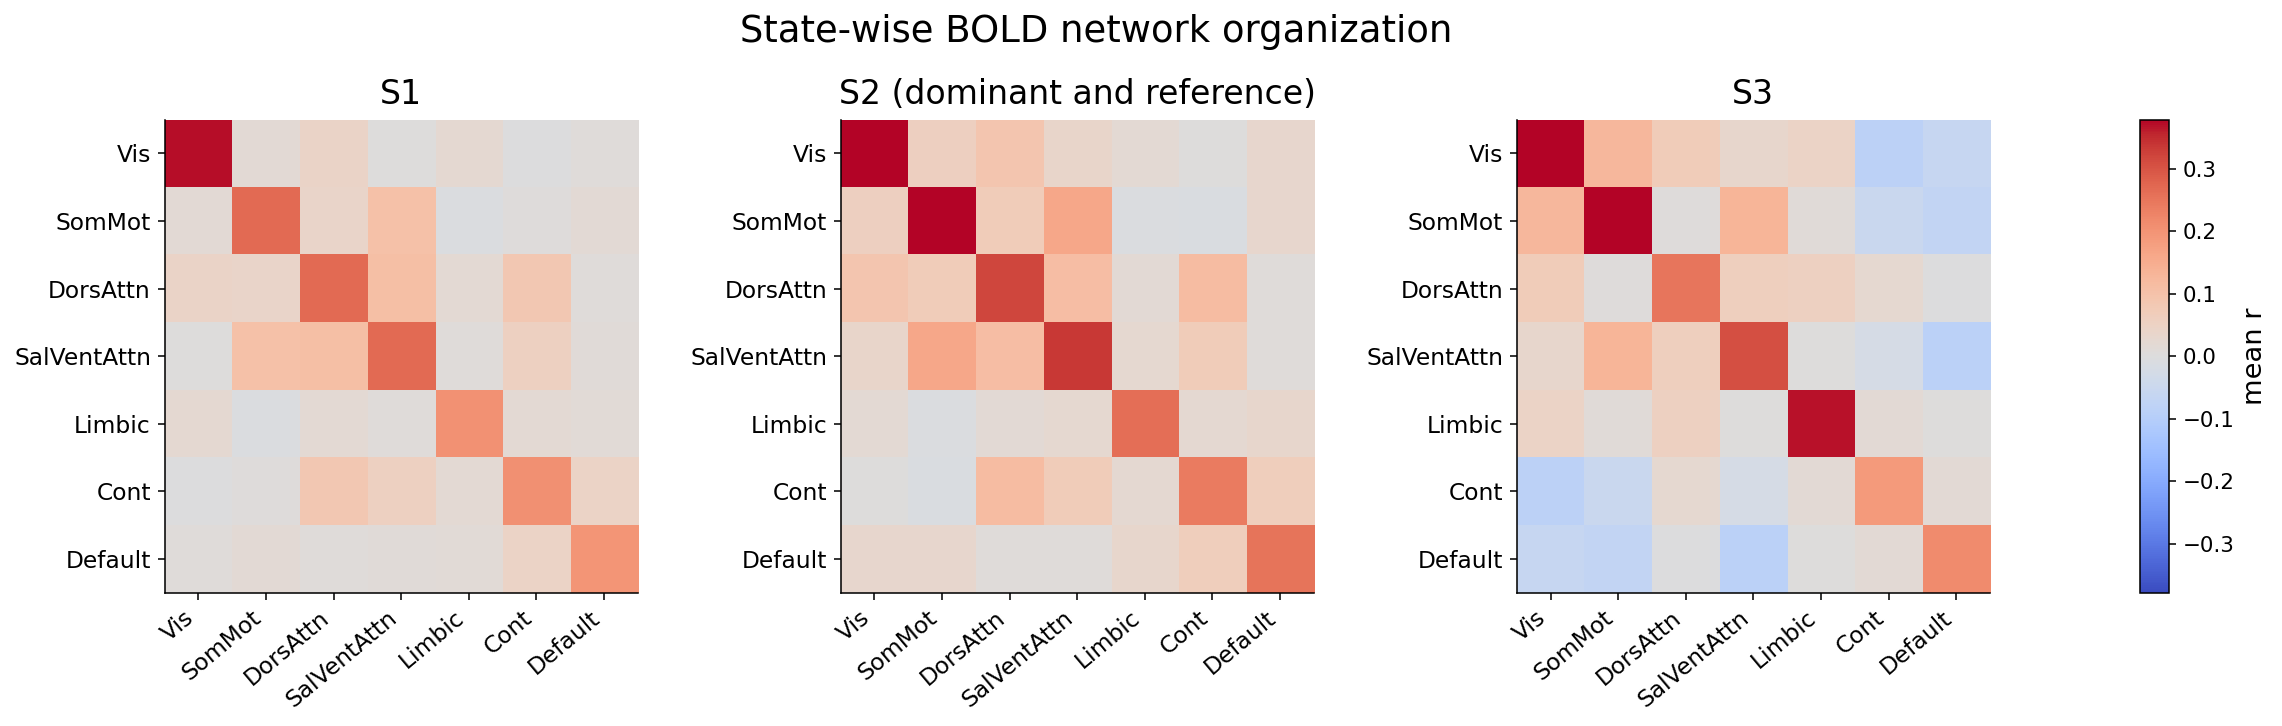

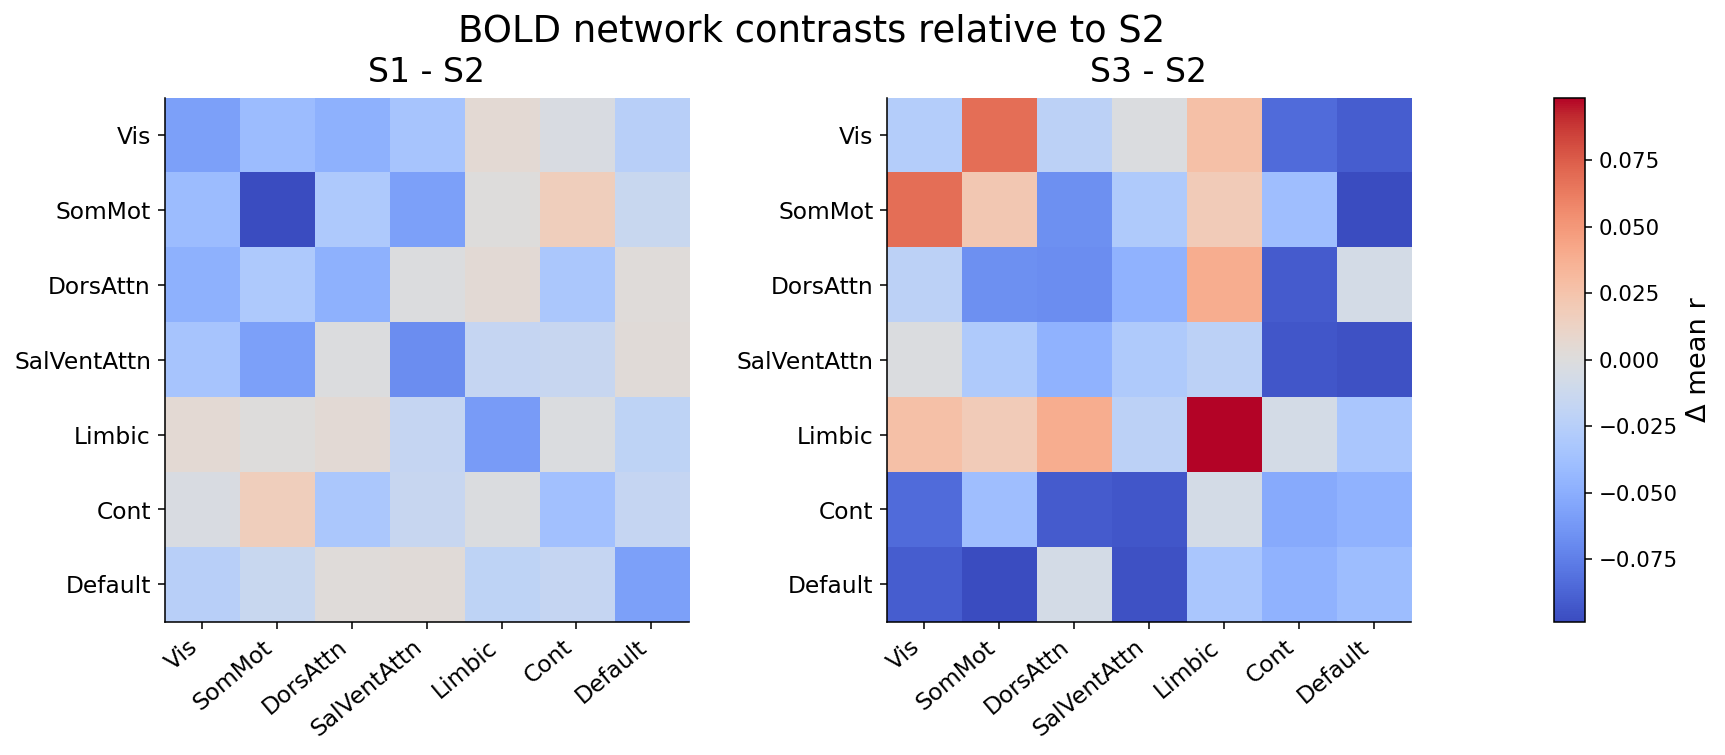

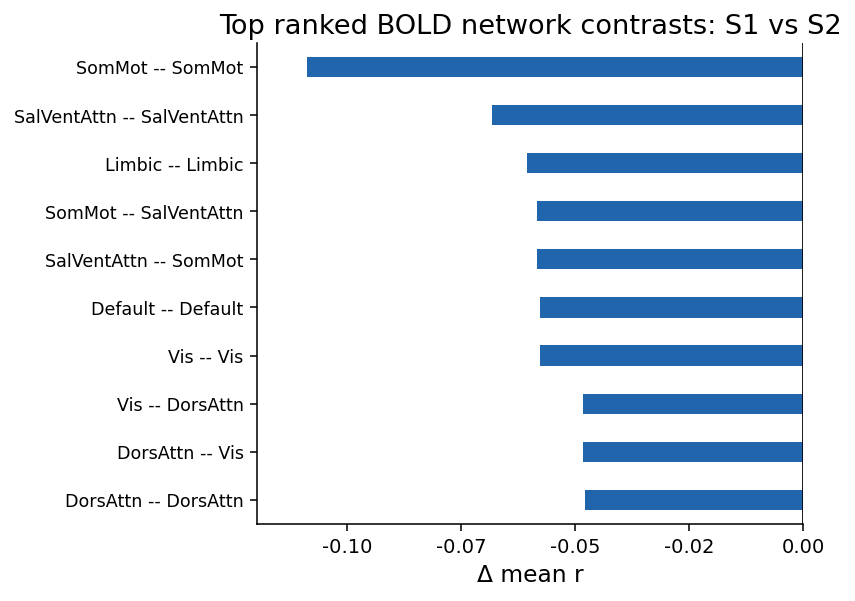

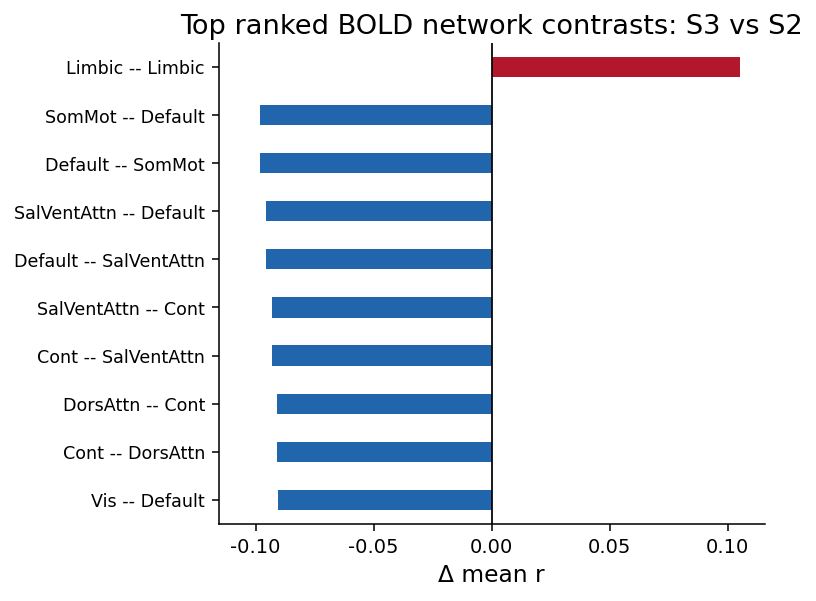

In [5]:

# =========================
# FIGURE 4 — SEPARATE PANEL EXPORTS
# =========================
state_keys = [f"S{i+1}" for i in range(len(bold_state_blocks))]
contrast_keys = [f"S{i+1} - S{ref_idx+1}" for i in range(len(bold_state_blocks)) if i != ref_idx]

bold_vmax_state = compute_symmetric_limits([bold_state_blocks[k].values for k in state_keys], quantile=0.98)
bold_vmax_diff = compute_symmetric_limits([bold_contrast_blocks[k].values for k in contrast_keys], quantile=0.98)


def export_fig4A_bold_states():
    fig = plt.figure(figsize=(15.8, 5.2), constrained_layout=False)
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.22)
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax = fig.add_subplot(gs[0, 3])

    im = None
    for ax, k in zip(axes, range(len(state_keys))):
        im = plot_block_heatmap(ax, bold_state_blocks[f"S{k+1}"], state_title(k, dominant_state_idx, ref_idx), bold_vmax_state)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("mean r")
    cb.ax.tick_params(labelsize=11)

    fig.suptitle("State-wise BOLD network organization", y=0.985, fontsize=19)
    fig.subplots_adjust(left=0.055, right=0.985, top=0.84, bottom=0.19, wspace=0.22)
    savefig(fig, "Fig4A_BOLD_states.png")


def export_fig4B_bold_contrasts():
    fig = plt.figure(figsize=(11.4, 5.2), constrained_layout=False)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.20)
    axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
    cax = fig.add_subplot(gs[0, 2])

    im = None
    for ax, cname in zip(axes, contrast_keys):
        im = plot_block_heatmap(ax, bold_contrast_blocks[cname], cname, bold_vmax_diff)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Δ mean r")
    cb.ax.tick_params(labelsize=11)

    fig.suptitle(f"BOLD network contrasts relative to S{ref_idx+1}", y=0.995, fontsize=19)
    fig.subplots_adjust(left=0.06, right=0.985, top=0.88, bottom=0.16, wspace=0.20)
    savefig(fig, "Fig4B_BOLD_contrasts.png")


def export_fig4C1_bold_ranked():
    fig, ax = plt.subplots(figsize=(6.0, 4.7), constrained_layout=False)
    plot_ranked_bars(ax, bold_rank_tables[contrast_keys[0]],
                     title=f"Top ranked BOLD network contrasts: {contrast_keys[0].replace(' - ', ' vs ')}",
                     xlabel="Δ mean r", top_n=TOP_N_BARS, label_fmt="{r} -- {c}", height=0.42,
                     x_decimals=2, max_xticks=5)
    fig.subplots_adjust(left=0.33, right=0.98, top=0.88, bottom=0.15)
    savefig(fig, "Fig4C1_BOLD_ranked_S1_vs_S2.png")


def export_fig4C2_bold_ranked():
    fig, ax = plt.subplots(figsize=(6.0, 4.7), constrained_layout=False)
    plot_ranked_bars(ax, bold_rank_tables[contrast_keys[1]],
                     title=f"Top ranked BOLD network contrasts: {contrast_keys[1].replace(' - ', ' vs ')}",
                     xlabel="Δ mean r", top_n=TOP_N_BARS, label_fmt="{r} -- {c}", height=0.42,
                     x_decimals=2, max_xticks=5)
    fig.subplots_adjust(left=0.33, right=0.98, top=0.88, bottom=0.15)
    savefig(fig, "Fig4C2_BOLD_ranked_S3_vs_S2.png")


export_fig4A_bold_states()
export_fig4B_bold_contrasts()
export_fig4C1_bold_ranked()
export_fig4C2_bold_ranked()


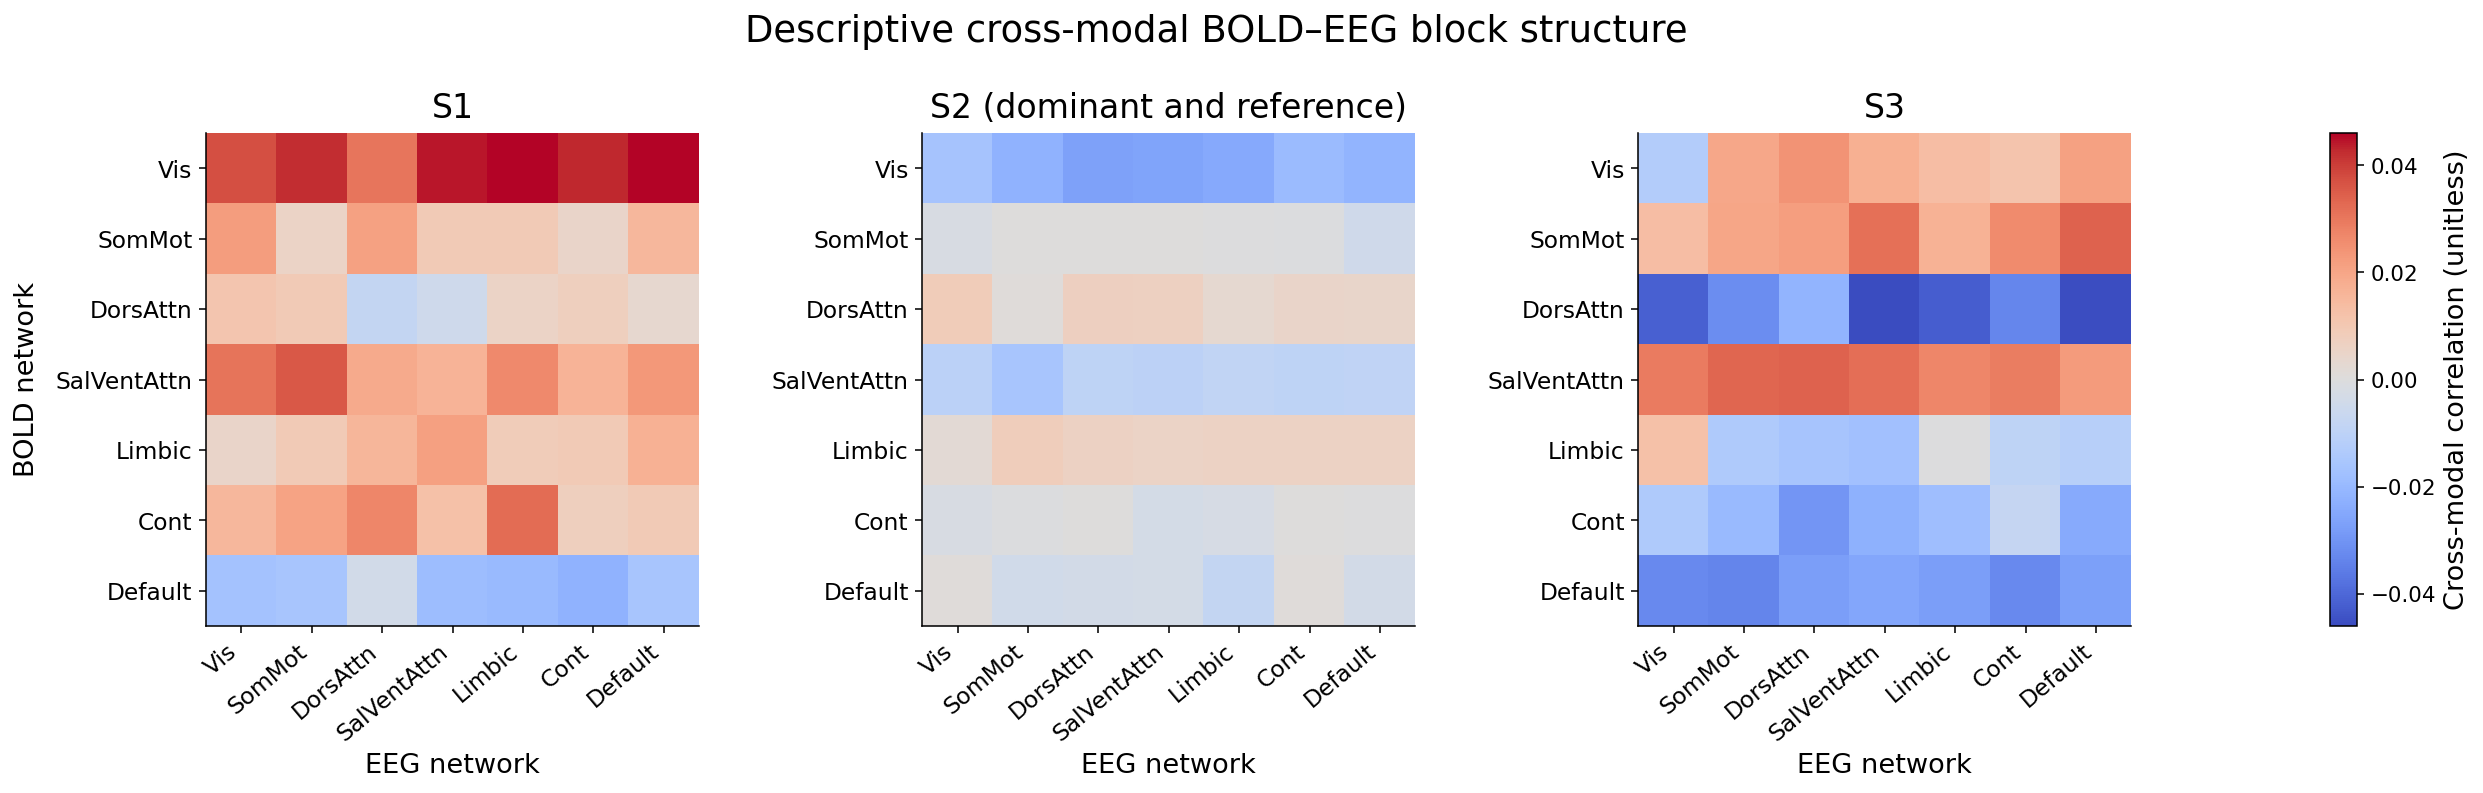

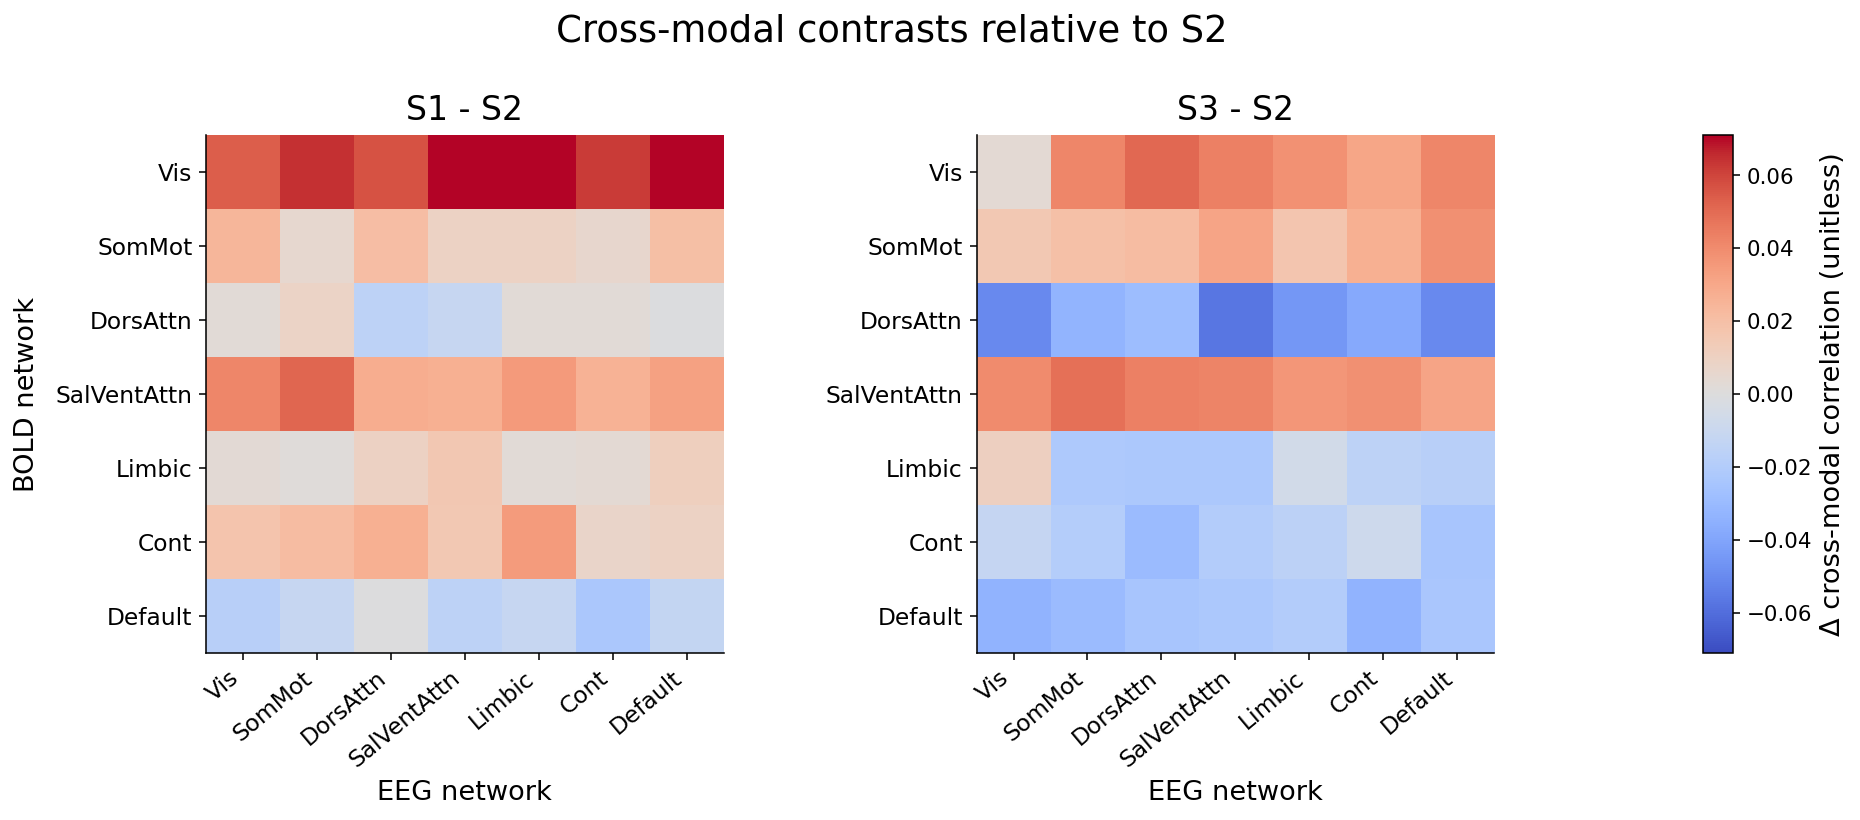

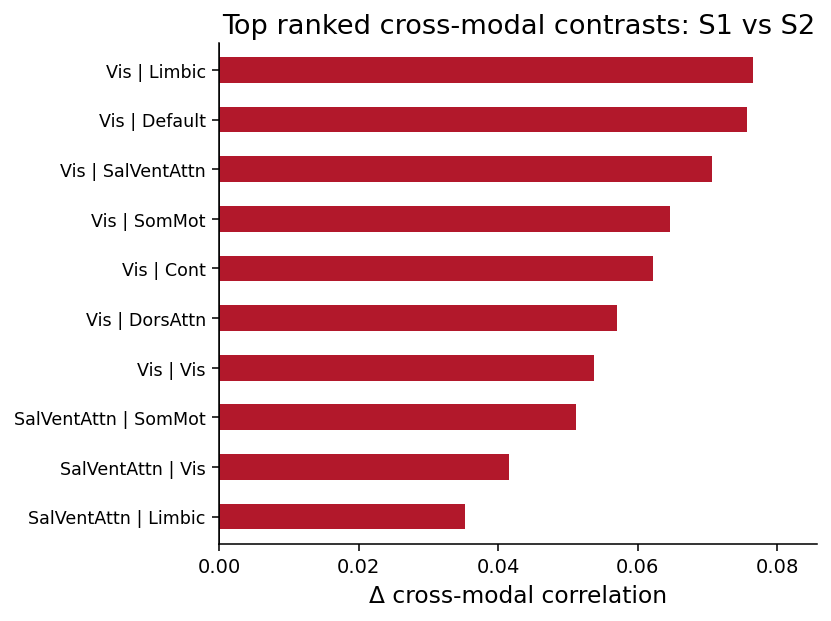

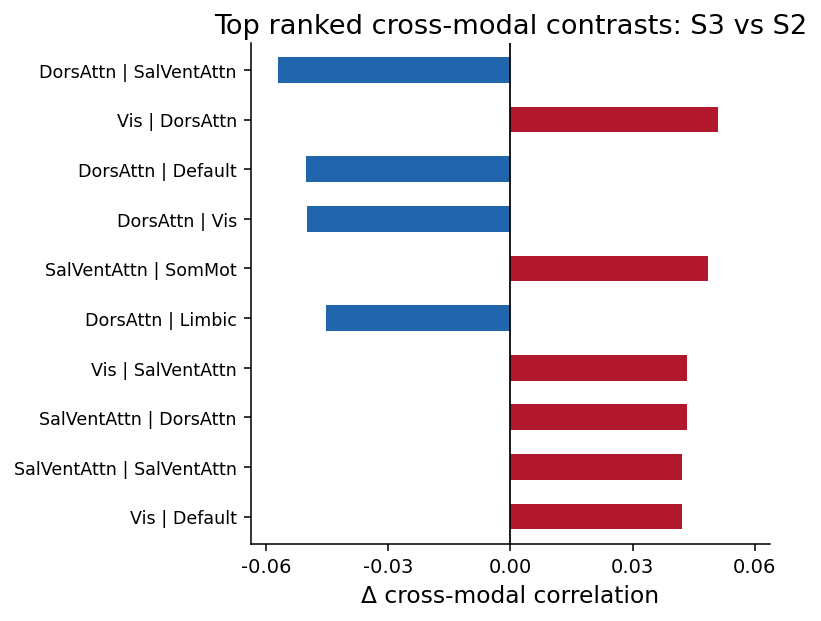

In [6]:

# =========================
# FIGURE 5 — SEPARATE PANEL EXPORTS
# =========================
state_keys_cross = [f"S{i+1}" for i in range(len(cross_state_blocks))]
contrast_keys_cross = [f"S{i+1} - S{ref_idx+1}" for i in range(len(cross_state_blocks)) if i != ref_idx]

cross_vmax_state = compute_symmetric_limits([cross_state_blocks[k].values for k in state_keys_cross], quantile=0.98)
cross_vmax_diff = compute_symmetric_limits([cross_contrast_blocks[k].values for k in contrast_keys_cross], quantile=0.98)


def export_fig5A_cross_states():
    fig = plt.figure(figsize=(16.8, 5.5), constrained_layout=False)
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.42)
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax = fig.add_subplot(gs[0, 3])

    im = None
    for idx, (ax, k) in enumerate(zip(axes, range(len(state_keys_cross)))):
        im = plot_block_heatmap(ax, cross_state_blocks[f"S{k+1}"], state_title(k, dominant_state_idx, ref_idx), cross_vmax_state)
        ax.set_xlabel("EEG network")
        ax.set_ylabel("BOLD network" if idx == 0 else "", labelpad=8)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Cross-modal correlation (unitless)")
    cb.ax.tick_params(labelsize=11)

    fig.suptitle("Descriptive cross-modal BOLD–EEG block structure", y=0.995, fontsize=19)
    fig.subplots_adjust(left=0.06, right=0.985, top=0.84, bottom=0.20, wspace=0.42)
    savefig(fig, "Fig5A_crossmodal_states.png")


def export_fig5B_cross_contrasts():
    fig = plt.figure(figsize=(12.4, 5.6), constrained_layout=False)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.40)
    axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
    cax = fig.add_subplot(gs[0, 2])

    im = None
    for idx, (ax, cname) in enumerate(zip(axes, contrast_keys_cross)):
        im = plot_block_heatmap(ax, cross_contrast_blocks[cname], cname, cross_vmax_diff)
        ax.set_xlabel("EEG network")
        ax.set_ylabel("BOLD network" if idx == 0 else "", labelpad=8)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Δ cross-modal correlation (unitless)")
    cb.ax.tick_params(labelsize=11)

    fig.suptitle(f"Cross-modal contrasts relative to S{ref_idx+1}", y=0.995, fontsize=19)
    fig.subplots_adjust(left=0.08, right=0.985, top=0.84, bottom=0.18, wspace=0.40)
    savefig(fig, "Fig5B_crossmodal_contrasts.png")


def export_fig5C1_cross_ranked():
    fig, ax = plt.subplots(figsize=(6.1, 4.9), constrained_layout=False)
    plot_ranked_bars(ax, cross_rank_tables[contrast_keys_cross[0]],
                     title=f"Top ranked cross-modal contrasts: {contrast_keys_cross[0].replace(' - ', ' vs ')}",
                     xlabel="Δ cross-modal correlation", top_n=TOP_N_BARS, label_fmt="{r} | {c}", height=0.52,
                     x_decimals=2, max_xticks=5, xpad_frac=0.12)
    fig.subplots_adjust(left=0.28, right=0.98, top=0.88, bottom=0.15)
    savefig(fig, "Fig5C1_crossmodal_ranked_S1_vs_S2.png")


def export_fig5C2_cross_ranked():
    fig, ax = plt.subplots(figsize=(6.4, 4.9), constrained_layout=False)
    plot_ranked_bars(ax, cross_rank_tables[contrast_keys_cross[1]],
                     title=f"Top ranked cross-modal contrasts: {contrast_keys_cross[1].replace(' - ', ' vs ')}",
                     xlabel="Δ cross-modal correlation", top_n=TOP_N_BARS, label_fmt="{r} | {c}", height=0.52,
                     x_decimals=2, max_xticks=5, xpad_frac=0.12)
    fig.subplots_adjust(left=0.40, right=0.98, top=0.88, bottom=0.15)
    savefig(fig, "Fig5C2_crossmodal_ranked_S3_vs_S2.png")


export_fig5A_cross_states()
export_fig5B_cross_contrasts()
export_fig5C1_cross_ranked()
export_fig5C2_cross_ranked()


In [7]:

# =========================
# OUTPUT MANIFEST
# =========================
manifest = pd.DataFrame([
    {"figure": "Fig4A", "panel": "BOLD states", "file": "Fig4A_BOLD_states.png"},
    {"figure": "Fig4B", "panel": "BOLD contrasts", "file": "Fig4B_BOLD_contrasts.png"},
    {"figure": "Fig4C1", "panel": "BOLD ranked S1 vs S2", "file": "Fig4C1_BOLD_ranked_S1_vs_S2.png"},
    {"figure": "Fig4C2", "panel": "BOLD ranked S3 vs S2", "file": "Fig4C2_BOLD_ranked_S3_vs_S2.png"},
    {"figure": "Fig5A", "panel": "Cross-modal states", "file": "Fig5A_crossmodal_states.png"},
    {"figure": "Fig5B", "panel": "Cross-modal contrasts", "file": "Fig5B_crossmodal_contrasts.png"},
    {"figure": "Fig5C1", "panel": "Cross-modal ranked S1 vs S2", "file": "Fig5C1_crossmodal_ranked_S1_vs_S2.png"},
    {"figure": "Fig5C2", "panel": "Cross-modal ranked S3 vs S2", "file": "Fig5C2_crossmodal_ranked_S3_vs_S2.png"},
])
manifest.to_csv(TAB_DIR / "fig4_fig5_panel_manifest.tsv", sep="	", index=False)
manifest


,figure,panel,file
0,Fig4A,BOLD states,Fig4A_BOLD_states.png
1,Fig4B,BOLD contrasts,Fig4B_BOLD_contrasts.png
2,Fig4C1,BOLD ranked S1 vs S2,Fig4C1_BOLD_ranked_S1_vs_S2.png
3,Fig4C2,BOLD ranked S3 vs S2,Fig4C2_BOLD_ranked_S3_vs_S2.png
4,Fig5A,Cross-modal states,Fig5A_crossmodal_states.png
5,Fig5B,Cross-modal contrasts,Fig5B_crossmodal_contrasts.png
6,Fig5C1,Cross-modal ranked S1 vs S2,Fig5C1_crossmodal_ranked_S1_vs_S2.png
7,Fig5C2,Cross-modal ranked S3 vs S2,Fig5C2_crossmodal_ranked_S3_vs_S2.png
